In [4]:
print("FAKE NEWS DETECTION PROJECT ✅")
import sys
print("Python Version:", sys.version)
print("Kernel Connected Successfully 🚀")
print("Ready for Zoho Submission 💪")

FAKE NEWS DETECTION PROJECT ✅
Python Version: 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]
Kernel Connected Successfully 🚀
Ready for Zoho Submission 💪


In [5]:
# Step 1: Install packages - 1st time mattum 1-2 mins edukum
!pip install pandas scikit-learn nltk matplotlib seaborn

# Step 2: Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

print("✅ All Libraries Imported Successfully")
print("✅ Ready to Load Data")

✅ All Libraries Imported Successfully
✅ Ready to Load Data



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jerin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
# True.csv & Fake.csv load pannu
df_true = pd.read_csv('True.csv')
df_fake = pd.read_csv('Fake.csv')

# Label add pannu: 1 = True News, 0 = Fake News
df_true['label'] = 1
df_fake['label'] = 0

# Rendum serthu oru dataset aaku
df = pd.concat([df_true, df_fake], ignore_index=True)

print("Dataset Shape:", df.shape)
print("\n✅ Data Loaded Successfully")
print("\nTrue News Count:", len(df_true))
print("Fake News Count:", len(df_fake))
print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (44898, 5)

✅ Data Loaded Successfully

True News Count: 21417
Fake News Count: 23481

First 5 Rows:


,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [7]:
df = df.dropna()
X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)
print("Training Data Size:", X_train.shape[0])
print("Testing Data Size:", X_test.shape[0])
print("✅ Data Split Successfully")

Training Data Size: 35918
Testing Data Size: 8980
✅ Data Split Successfully


In [8]:
# TF-IDF Vectorizer - text ah numbers ah maathum
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)
tfidf_train = tfidf_vectorizer.fit_transform(X_train)
tfidf_test = tfidf_vectorizer.transform(X_test)

# PassiveAggressiveClassifier Model
pac = PassiveAggressiveClassifier(max_iter=50)
pac.fit(tfidf_train, y_train)

print("✅ Model Training Completed")
print("✅ Ready for Prediction")

✅ Model Training Completed
✅ Ready for Prediction


c:\Users\jerin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


🎯 Accuracy: 99.55%

Confusion Matrix:
[[4653   22]
 [  18 4287]]


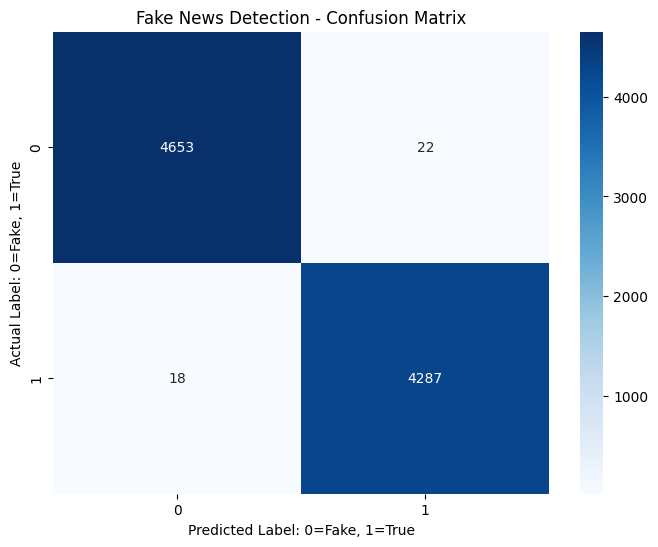


🚀 PROJECT COMPLETED 
✅ You can now submit this notebook


In [10]:
# Prediction pannu
y_pred = pac.predict(tfidf_test)

# Accuracy calculate pannu
score = accuracy_score(y_test, y_pred)
print(f'🎯 Accuracy: {round(score*100,2)}%')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Visualize pannu
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Fake News Detection - Confusion Matrix')
plt.ylabel('Actual Label: 0=Fake, 1=True')
plt.xlabel('Predicted Label: 0=Fake, 1=True')
plt.show()

print("\n🚀 PROJECT COMPLETED ")
print("✅ You can now submit this notebook")